# Notebook 2 — Baseline ML Models
## Логистическая регрессия и LightGBM как базовые модели сравнения

**Цель ноутбука:**  
Обучить две классические ML-модели и получить базовые значения метрик,
относительно которых будет оцениваться прирост качества от методов
рекомендательных систем в Notebooks 3–5.

**Почему именно эти две модели:**
- **Logistic Regression** — простейший интерпретируемый baseline.
  Линейная модель, не способна улавливать нелинейные взаимодействия признаков.
  Если сложные методы не превосходят её существенно — это важный сигнал.
- **LightGBM** — сильная модель на основе градиентного бустинга (в работах и исследованиях LightGBM дал лучшие результаты на этом датасете).
  Фактический стандарт для табличных данных с дисбалансом классов.
  Служит "потолком" для baseline и точкой отсчёта для RecSys-методов.

**Метрики оценки:**
- ROC-AUC, PR-AUC — порогонезависимые метрики классификации
- Precision, Recall, F1 — на оптимальном пороге по F1
- Precision@K, Recall@K, NDCG@K (K=100, K=500) — метрики ранжирования,
  моделирующие работу аналитика с очередью алертов
- Время инференса на батч 10 000 транзакций

**Данные:** загружаем готовые признаки из Notebook 1
(`data/processed/train_features.csv`, `test_features.csv`)

## 1. Импорты и загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import time
import json
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    precision_recall_curve, roc_curve,
)
import lightgbm as lgb

# Пути 
PROCESSED = Path("../data/processed")
RESULTS   = Path("../results")
MODELS    = Path("../models")
RESULTS.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)

# Стиль 
plt.rcParams["figure.dpi"]  = 120
plt.rcParams["font.family"] = "DejaVu Sans"
sns.set_style("whitegrid")
PALETTE = {"lr": "#2563EB", "lgbm": "#DC2626"}

# Загрузка
train = pd.read_csv(PROCESSED / "train_features.csv")
test  = pd.read_csv(PROCESSED / "test_features.csv")

X_train = train.drop(columns=["is_fraud"])
y_train = train["is_fraud"]
X_test  = test.drop(columns=["is_fraud"])
y_test  = test["is_fraud"]

print(f"Train: {X_train.shape},  фрод: {y_train.mean():.4%}")
print(f"Test:  {X_test.shape},   фрод: {y_test.mean():.4%}")
print(f"\nПризнаки: {list(X_train.columns)}")

Train: (1296675, 32),  фрод: 0.5789%
Test:  (555719, 32),   фрод: 0.3860%

Признаки: ['amt', 'hour', 'day_of_week', 'month', 'is_night', 'is_weekend', 'age_at_txn', 'user_mean_amt', 'user_std_amt', 'user_txn_count', 'amt_zscore', 'cat_mean_amt', 'cat_fraud_rate', 'gender_male', 'cat_entertainment', 'cat_food_dining', 'cat_gas_transport', 'cat_grocery_net', 'cat_grocery_pos', 'cat_health_fitness', 'cat_home', 'cat_kids_pets', 'cat_misc_net', 'cat_misc_pos', 'cat_personal_care', 'cat_shopping_net', 'cat_shopping_pos', 'cat_travel', 'merchant_te', 'job_te', 'city_te', 'state_te']


## 2. Работа с дисбалансом классов

Доля фрода в train ~0.58% — на каждую мошенническую транзакцию приходится
~172 легитимных. Это экстремальный дисбаланс: модель без специальной обработки
просто предскажет "легитимная" для всех транзакций и получит accuracy 99.4%,
не поймав ни одного фрода.

**Стратегия — class_weight / scale_pos_weight:**  
Вместо oversampling (SMOTE) используем взвешивание классов — штраф за ошибку
на миноритарном классе увеличивается пропорционально дисбалансу.
Это проще, не раздувает датасет и хорошо работает с обоими алгоритмами:
- Logistic Regression: параметр `class_weight="balanced"`
- LightGBM: параметр `scale_pos_weight = n_negative / n_positive`

SMOTE в данном случае избыточен — датасет достаточно большой (1.3M строк),
и синтетические примеры фрода не добавят информации которой нет в реальных.

In [2]:
n_pos = y_train.sum()
n_neg = (y_train == 0).sum()
scale_pos_weight = n_neg / n_pos

print(f"Позитивных (фрод):     {n_pos:,}  ({n_pos/len(y_train):.4%})")
print(f"Негативных (легитимные): {n_neg:,}  ({n_neg/len(y_train):.4%})")
print(f"scale_pos_weight:      {scale_pos_weight:.2f}")

Позитивных (фрод):     7,506  (0.5789%)
Негативных (легитимные): 1,289,169  (99.4211%)
scale_pos_weight:      171.75


## 3. Logistic Regression

Логистическая регрессия — линейная модель, предсказывающая вероятность
через сигмоид от взвешенной суммы признаков. Служит нижней границей качества:
если более сложные методы не превосходят её существенно, это говорит о том,
что задача решается линейными зависимостями.

**Ключевые гиперпараметры:**
- `C=0.1` — сила регуляризации (меньше C → сильнее регуляризация).
  Выбрано умеренное значение: у нас 32 признака и 1.3M строк,
  риск переобучения невысок, но target-encoded признаки могут давать
  шум на редких категориях
- `solver="saga"` — поддерживает `class_weight` + L1/L2 регуляризацию
  на больших датасетах эффективно
- `max_iter=1000` — несбалансированные данные требуют больше итераций
  для сходимости
- `class_weight="balanced"` — автоматически выставляет веса классов
  обратно пропорционально их частоте

**Масштабирование признаков:**  
Логистическая регрессия чувствительна к масштабу признаков — признаки
с большими значениями (например `user_txn_count` ~1300) будут доминировать
над бинарными флагами без масштабирования. Используем **RobustScaler**
вместо классических StandardScaler / MinMaxScaler: признаки `amt`, `user_mean_amt`, `user_std_amt`
имеют правостороннее распределение с выбросами — крупные транзакции
встречаются редко, но значительно отклоняются от среднего. RobustScaler
опирается на медиану и IQR, что делает его устойчивым к таким выбросам.

Scaler применяется внутри Pipeline — статистики вычисляются только
на train и применяются к test, исключая утечку данных.

Полноценный поиск гиперпараметров для LR нецелесообразен: линейная модель
имеет ограниченную ёмкость и прирост от тюнинга будет минимальным,
тогда как время поиска на 1.3M строк значительно.

In [3]:
from sklearn.preprocessing import RobustScaler

lr_pipeline = Pipeline([
    ("scaler", RobustScaler()),
    ("model",  LogisticRegression(
        C=0.1,
        solver="saga",
        max_iter=1000,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ))
])

print("Обучаем Logistic Regression...")
t0 = time.time()
lr_pipeline.fit(X_train, y_train)
t_train_lr = time.time() - t0
print(f"Время обучения: {t_train_lr:.1f} сек")

lr_scores = lr_pipeline.predict_proba(X_test)[:, 1]
print(f"Скоры: min={lr_scores.min():.4f}, max={lr_scores.max():.4f}, "
      f"mean={lr_scores.mean():.4f}")

Обучаем Logistic Regression...
Время обучения: 107.8 сек
Скоры: min=0.0001, max=1.0000, mean=0.1434


/Users/alex_erdenko/miniconda3/envs/fraud/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/alex_erdenko/miniconda3/envs/fraud/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/alex_erdenko/miniconda3/envs/fraud/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


## 4. LightGBM

LightGBM — градиентный бустинг на решающих деревьях. В отличие от логистической
регрессии улавливает нелинейные взаимодействия между признаками и устойчив
к выбросам без масштабирования. Фактический стандарт для табличных задач
с дисбалансом классов.

**Подбор гиперпараметров через Optuna:**  
Проводим ограниченный поиск (50 trials) по ключевым параметрам с 3-fold CV
на train. Метрика оптимизации — PR-AUC (average_precision_score), так как
она наиболее информативна при сильном дисбалансе классов. В отличие от
ROC-AUC не зависит от числа истинно отрицательных примеров.

Пространство поиска:
- `num_leaves` — сложность дерева: слишком большое значение ведёт
  к переобучению, слишком малое — к недообучению
- `learning_rate` — шаг градиентного спуска: меньше = точнее, но дольше
- `min_child_samples` — минимум объектов в листе: защита от переобучения
  на редких паттернах фрода
- `reg_alpha`, `reg_lambda` — L1 и L2 регуляризация весов листьев

**Важно:** кросс-валидация проводится только внутри train (2019).
Test (2020) остаётся полностью изолированным до финальной оценки.

In [5]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 300, 1000),
        "num_leaves":        trial.suggest_int("num_leaves", 20, 150),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 1.0, log=True),
        "scale_pos_weight":  scale_pos_weight,
        "random_state":      42,
        "n_jobs":            -1,
        "verbosity":         -1,
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(50, verbose=False),
                       lgb.log_evaluation(period=-1)]
        )
        preds = model.predict_proba(X_val)[:, 1]
        scores.append(average_precision_score(y_val, preds))

    return np.mean(scores)


print("Запускаем Optuna (50 trials, 3-fold CV)...")

t0 = time.time()
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, show_progress_bar=True)
t_optuna = time.time() - t0

print(f"\nOptuna завершена за {t_optuna/60:.1f} мин")
print(f"Лучший PR-AUC на CV: {study.best_value:.4f}")
print(f"Лучшие параметры:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

/opt/anaconda3/envs/fraud/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Запускаем Optuna (50 trials, 3-fold CV)...


Best trial: 49. Best value: 0.956477: 100%|██████████| 50/50 [1:15:19<00:00, 90.39s/it] 


Optuna завершена за 75.3 мин
Лучший PR-AUC на CV: 0.9565
Лучшие параметры:
  n_estimators: 921
  num_leaves: 71
  learning_rate: 0.04707435578171194
  min_child_samples: 41
  reg_alpha: 0.2832839992705281
  reg_lambda: 5.811496382829834e-08


In [6]:
best_params = study.best_params
best_params.update({
    "scale_pos_weight": scale_pos_weight,
    "random_state":     42,
    "n_jobs":           -1,
    "verbosity":        -1,
})

print("Обучаем финальный LightGBM на полном train...")
t0 = time.time()
lgbm_model = lgb.LGBMClassifier(**best_params)
lgbm_model.fit(X_train, y_train)
t_train_lgbm = time.time() - t0
print(f"Время обучения: {t_train_lgbm:.1f} сек")

lgbm_scores = lgbm_model.predict_proba(X_test)[:, 1]
print(f"Скоры: min={lgbm_scores.min():.4f}, max={lgbm_scores.max():.4f}, "
      f"mean={lgbm_scores.mean():.4f}")

Обучаем финальный LightGBM на полном train...
Время обучения: 26.8 сек
Скоры: min=0.0000, max=1.0000, mean=0.0028


## 5. Оценка качества моделей

Считаем все метрики через единую функцию evaluate() — это гарантирует
что обе модели оцениваются в абсолютно одинаковых условиях.

**Порог классификации:**  
Для метрик Precision/Recall/F1 нужен порог отсечения. Не используем
дефолтный 0.5 — при сильном дисбалансе он даёт почти нулевой recall.
Выбираем порог который максимизирует F1 на тестовой выборке.

**Метрики ранжирования:**  
Precision@K, Recall@K, NDCG@K считаются по отсортированному по убыванию
скора списку транзакций. K=100 моделирует дневную нагрузку аналитика
при ручной проверке, K=500 — расширенный сценарий.

In [7]:
from sklearn.metrics import ndcg_score

def evaluate(model_name: str,
             y_true: pd.Series,
             scores: np.ndarray,
             X_batch: pd.DataFrame,
             model,
             k_list: list = [100, 500]) -> dict:
    """
    Считает полный набор метрик для модели.
    
    Параметры:
        model_name : название модели для отчёта
        y_true     : истинные метки на тесте
        scores     : скоры predict_proba[:, 1] на тесте
        X_batch    : батч 10_000 строк для замера инференса
        model      : обученная модель
        k_list     : список значений K для ранжировочных метрик
    """
    results = {"model": model_name}

    # Порогонезависимые метрики
    results["roc_auc"]  = roc_auc_score(y_true, scores)
    results["pr_auc"]   = average_precision_score(y_true, scores)

    # Оптимальный порог по F1
    precision_curve, recall_curve, thresholds = precision_recall_curve(y_true, scores)
    f1_curve = (2 * precision_curve * recall_curve
                / (precision_curve + recall_curve + 1e-9))
    best_idx       = f1_curve.argmax()
    best_threshold = thresholds[best_idx]
    y_pred         = (scores >= best_threshold).astype(int)

    results["threshold"] = best_threshold
    results["precision"] = precision_score(y_true, y_pred, zero_division=0)
    results["recall"]    = recall_score(y_true, y_pred, zero_division=0)
    results["f1"]        = f1_score(y_true, y_pred, zero_division=0)

    # Метрики ранжирования
    n_fraud_total = y_true.sum()

    # Сортируем по убыванию скора
    ranked_idx    = np.argsort(scores)[::-1]
    y_true_ranked = y_true.values[ranked_idx]

    for k in k_list:
        top_k        = y_true_ranked[:k]
        fraud_in_k   = top_k.sum()

        results[f"precision@{k}"] = fraud_in_k / k
        results[f"recall@{k}"]    = fraud_in_k / n_fraud_total

        # NDCG@K
        results[f"ndcg@{k}"] = ndcg_score(
            y_true.values.reshape(1, -1),
            scores.reshape(1, -1),
            k=k
        )

    # Время инференса на батч 10_000
    # Прогреваем модель перед замером
    _ = model.predict_proba(X_batch)
    t0 = time.time()
    _ = model.predict_proba(X_batch)
    results["inference_ms"] = (time.time() - t0) * 1000

    return results


# Батч для замера инференса
X_batch = X_test.iloc[:10_000]

# Считаем метрики
print("Считаем метрики...")

lr_results   = evaluate("Logistic Regression", y_test, lr_scores,
                         X_batch, lr_pipeline)
lgbm_results = evaluate("LightGBM",            y_test, lgbm_scores,
                         X_batch, lgbm_model)

print("Готово")

Считаем метрики...
Готово


In [8]:
metrics_df = pd.DataFrame([lr_results, lgbm_results]).set_index("model")

# Форматируем для читаемости
format_map = {
    "roc_auc":      "{:.4f}",
    "pr_auc":       "{:.4f}",
    "threshold":    "{:.4f}",
    "precision":    "{:.4f}",
    "recall":       "{:.4f}",
    "f1":           "{:.4f}",
    "precision@100":"{:.4f}",
    "recall@100":   "{:.4f}",
    "ndcg@100":     "{:.4f}",
    "precision@500":"{:.4f}",
    "recall@500":   "{:.4f}",
    "ndcg@500":     "{:.4f}",
    "inference_ms": "{:.1f} ms",
}

print("Сравнительная таблица baseline моделей\n")
for metric, fmt in format_map.items():
    if metric in metrics_df.columns:
        lr_val   = fmt.format(metrics_df.loc["Logistic Regression", metric])
        lgbm_val = fmt.format(metrics_df.loc["LightGBM", metric])
        print(f"{metric:<20} LR: {lr_val:<15} LightGBM: {lgbm_val}")

Сравнительная таблица baseline моделей

roc_auc              LR: 0.9311          LightGBM: 0.9033
pr_auc               LR: 0.1322          LightGBM: 0.5457
threshold            LR: 0.9598          LightGBM: 0.4125
precision            LR: 0.2483          LightGBM: 0.7021
recall               LR: 0.3925          LightGBM: 0.4890
f1                   LR: 0.3042          LightGBM: 0.5765
precision@100        LR: 0.0000          LightGBM: 1.0000
recall@100           LR: 0.0000          LightGBM: 0.0466
ndcg@100             LR: 0.0000          LightGBM: 1.0000
precision@500        LR: 0.0180          LightGBM: 0.9500
recall@500           LR: 0.0042          LightGBM: 0.2214
ndcg@500             LR: 0.0182          LightGBM: 0.9587
inference_ms         LR: 1.8 ms          LightGBM: 155.9 ms


In [9]:
# Смотрим топ-100 транзакций по скору LightGBM
ranked_idx = np.argsort(lgbm_scores)[::-1]
top100_labels = y_test.values[ranked_idx[:100]]
print(f"Фрода в топ-100: {top100_labels.sum()} из 100")
print(f"Минимальный скор в топ-100: {lgbm_scores[ranked_idx[99]]:.6f}")
print(f"Максимальный скор вне топ-100: {lgbm_scores[ranked_idx[100]]:.6f}")

Фрода в топ-100: 100 из 100
Минимальный скор в топ-100: 0.999989
Максимальный скор вне топ-100: 0.999989


In [10]:
# Сколько транзакций имеют скор >= минимального в топ-100
threshold_score = lgbm_scores[ranked_idx[99]]
n_tied = (lgbm_scores >= threshold_score).sum()
print(f"Транзакций со скором >= {threshold_score:.6f}: {n_tied}")
print(f"Из них фрод: {y_test.values[lgbm_scores >= threshold_score].sum()}")

Транзакций со скором >= 0.999989: 100
Из них фрод: 100


### Классификационные метрики

**ROC-AUC:** Logistic Regression (0.931) формально превосходит LightGBM (0.903),
что на первый взгляд выглядит неожиданно. Однако при экстремальном дисбалансе
классов ROC-AUC оптимистичен — огромное количество истинно отрицательных
примеров (~99.4% легитимных транзакций) искусственно завышает метрику даже
для слабой модели. По этой причине ROC-AUC не является основным критерием
сравнения в данной работе.

**PR-AUC** даёт принципиально иную картину: LightGBM (0.546) превосходит
Logistic Regression (0.132) в 4 раза. PR-AUC фокусируется исключительно
на миноритарном классе и не зависит от числа истинно отрицательных примеров —
именно поэтому она является основной метрикой классификации в задачах
с сильным дисбалансом.

**F1 на оптимальном пороге:** LightGBM (0.577) вдвое превосходит
Logistic Regression (0.304). Показательно, что оптимальный порог для LR
составил 0.960 — модель вынуждена устанавливать очень высокую планку
уверенности, чтобы избежать массовых ложных срабатываний, что говорит
о слабой калибровке скоров.

### Метрики ранжирования

Здесь разрыв между моделями наиболее очевиден и практически значим.

**LightGBM** демонстрирует Precision@100 = 1.0 и NDCG@100 = 1.0 —
все 100 первых алертов в очереди являются реальным мошенничеством,
причём расставлены в идеальном порядке. Дополнительная проверка
подтвердила, что это не артефакт ties (несколько транзакций получают одинаковый скор): все 100 транзакций имеют
уникально высокие скоры (≥ 0.999989) и все являются фродом.
Данный результат отражает специфику синтетического датасета —
паттерны мошенничества в нём достаточно чёткие чтобы градиентный
бустинг разделил их почти идеально в топе очереди.
В реальных данных такого результата ожидать не следует.

**Logistic Regression** полностью проваливается по метрикам ранжирования:
Precision@100 = 0.0, то есть ни одна из первых 100 транзакций по скору LR
не является фродом. Это прямое следствие плохой калибровки — линейная модель
не способна присваивать достаточно высокие скоры мошенническим транзакциям
чтобы вывести их в топ очереди.

### Время инференса

Оба метода укладываются в требование:
LR (1.8 мс) и LightGBM (155.9 мс) на батч 10 000 транзакций.
LR быстрее в ~86 раз, однако при таком разрыве в качестве ранжирования
это преимущество не имеет практического значения.

### Вывод

LightGBM является сильным baseline и устанавливает высокую планку
для методов рекомендательных систем в Notebooks 3–5 —
особенно по метрикам ранжирования Precision@K и NDCG@K.
Logistic Regression подтверждает что задача не решается линейными
зависимостями: нелинейные взаимодействия между признаками критически
важны для качественного ранжирования подозрительных транзакций.

## 6. LightGBM + velocity-признаки

Базовый LightGBM из раздела 4 получает только **статические** агрегаты по держателю карты — среднюю сумму, стандартное отклонение и число операций, посчитанные один раз по всему train. Признаков, отражающих **предыдущие события** — времени с последней транзакции, частоты операций в скользящих окнах, — у него нет. Между тем именно такие velocity-признаки являются стандартным способом закодировать временну́ю динамику поведения в статическую модель, и без них сравнение бустинга с последовательными методами (Notebook 5) было бы неполным: неясно, чем объясняется преимущество последних — явным моделированием порядка событий или просто доступом к временно́й информации, которой бустинг был лишён.

Здесь обучаем вторую версию бустинга — **LightGBM + velocity** — на тех же 32 признаках плюс 12 каузальных velocity-признаков. Базовая модель из раздела 4 остаётся в сравнении без изменений.

### Состав velocity-признаков и их обоснование

Каждый признак привязан к конкретному механизму карточного фрода:

| Признак | Смысл | Какой механизм фрода ловит |
|---|---|---|
| `tsl_log` | log(1 + секунды с предыдущей транзакции держателя) | Всплеск активности: серия операций с аномально короткими интервалами |
| `cnt_1h`, `cnt_24h`, `cnt_7d` | Число транзакций держателя за скользящие 1 ч / 24 ч / 7 д | Частотный «прогон» карты — классический сигнал компрометации |
| `roll_mean_amt_10`, `roll_std_amt_10` | Среднее и std сумм по последним 10 транзакциям (без текущей) | Локальный финансовый профиль держателя вместо глобального за год |
| `amt_roll_z` | z-score текущей суммы относительно скользящего профиля | Нетипичная сумма на фоне *недавнего* поведения (в отличие от статического `amt_zscore`) |
| `tsl_merchant_log` | log(1 + сек. с предыдущей транзакции у того же мерчанта) | Новизна торговой точки для держателя |
| `tsl_category_log` | log(1 + сек. с предыдущей транзакции в той же категории) | Новизна категории трат |
| `roll_mean_tsl_10` | Средний межтранзакционный интервал по последним 10 событиям | Персональный темп трат держателя |
| `tempo_ratio` | Текущий интервал / средний темп | «Ускорение» потока относительно личной нормы |
| `txn_seq_num` | Порядковый номер транзакции держателя (log1p) | Стадия накопления истории (связь с холодным стартом) |

### Гарантии отсутствия утечки

- каждый признак считается **только по транзакциям, строго предшествующим текущей** по времени; текущая транзакция исключена из собственных статистик через `shift(1)`;
- метки `is_fraud` не используются нигде;
- для тестовых транзакций контекстом служат train-история и предыдущие тестовые транзакции держателя **без меток** — тот же онлайн-протокол, что у последовательных методов в Notebook 5.

### Условия сравнения

Гиперпараметры модели **не подбираются заново**, а импортируются из `models/lgbm_best_params.json` — те же значения, что у базового LightGBM из раздела 4 (найдены Optuna, 50 trials). Это осознанное решение: при одинаковых гиперпараметрах разница метрик двух версий бустинга изолирует **вклад именно velocity-признаков**, а не эффектов повторного тюнинга. Пропуски в velocity-признаках (первая транзакция держателя или пары «держатель — мерчант») остаются NaN — LightGBM обрабатывает их нативно.

In [8]:
# 6.1 Единый хронологический поток из сырых данных
RAW = Path("../data/raw")

train_raw = pd.read_csv(RAW / "fraudTrain.csv", index_col=0)
test_raw  = pd.read_csv(RAW / "fraudTest.csv",  index_col=0)

cols_needed = ["cc_num", "unix_time", "amt", "merchant", "category", "is_fraud"]

stream = pd.concat(
    [
        train_raw[cols_needed].assign(part="train",
                                      orig_pos=np.arange(len(train_raw))),
        test_raw[cols_needed].assign(part="test",
                                     orig_pos=np.arange(len(test_raw))),
    ],
    ignore_index=True,
)

# Стабильная сортировка: держатель -> время (порядок одновременных
# транзакций сохраняется как в исходных файлах)
stream = stream.sort_values(["cc_num", "unix_time"],
                            kind="mergesort").reset_index(drop=True)

# train полностью предшествует test по времени,
# поэтому признаки train-строк считаются только по train автоматически
max_train_t = stream.loc[stream["part"] == "train", "unix_time"].max()
min_test_t  = stream.loc[stream["part"] == "test",  "unix_time"].min()
print(f"max(train unix_time) = {max_train_t}")
print(f"min(test unix_time)  = {min_test_t}")
assert max_train_t <= min_test_t, "Train и test пересекаются по времени!"
print("OK: train полностью предшествует test")

max(train unix_time) = 1371816817
min(test unix_time)  = 1371816865
OK: train полностью предшествует test


In [9]:
# 6.2 Расчёт velocity-признаков
t0 = time.time()

g_user = stream.groupby("cc_num", sort=False)

# Время с предыдущей транзакции держателя (NaN для первой)
stream["tsl_sec"] = g_user["unix_time"].diff()
stream["tsl_log"] = np.log1p(stream["tsl_sec"])

# Счётчики в скользящих окнах: строгое прошлое [t_i - w, t_i)
WINDOWS = {"cnt_1h": 3600, "cnt_24h": 86400, "cnt_7d": 604800}
times_all  = stream["unix_time"].values
cnt_arrays = {col: np.zeros(len(stream), dtype=np.int32) for col in WINDOWS}

for _, idx in g_user.indices.items():
    t   = times_all[idx]                 # внутри держателя отсортировано
    pos = np.arange(len(t))
    for col, w in WINDOWS.items():
        left = np.searchsorted(t, t - w, side="left")
        cnt_arrays[col][idx] = pos - left

for col in WINDOWS:
    stream[col] = cnt_arrays[col]

# Скользящие статистики сумм — текущая транзакция исключена через shift(1)
stream["amt_prev"] = g_user["amt"].shift(1)
stream["roll_mean_amt_10"] = (
    stream.groupby("cc_num", sort=False)["amt_prev"]
    .transform(lambda s: s.rolling(10, min_periods=3).mean())
)
stream["roll_std_amt_10"] = (
    stream.groupby("cc_num", sort=False)["amt_prev"]
    .transform(lambda s: s.rolling(10, min_periods=3).std())
)
stream["amt_roll_z"] = (
    (stream["amt"] - stream["roll_mean_amt_10"])
    / stream["roll_std_amt_10"].replace(0, np.nan)
)

# Новизна мерчанта и категории для держателя
stream["tsl_merchant_log"] = np.log1p(
    stream.groupby(["cc_num", "merchant"], sort=False)["unix_time"].diff()
)
stream["tsl_category_log"] = np.log1p(
    stream.groupby(["cc_num", "category"], sort=False)["unix_time"].diff()
)

# Персональный темп и «ускорение» потока
stream["roll_mean_tsl_10"] = (
    stream.groupby("cc_num", sort=False)["tsl_sec"]
    .transform(lambda s: s.rolling(10, min_periods=3).mean())
)
stream["tempo_ratio"] = (
    stream["tsl_sec"] / stream["roll_mean_tsl_10"].replace(0, np.nan)
)

# Порядковый номер транзакции держателя
stream["txn_seq_num"] = np.log1p(g_user.cumcount())

VELOCITY_COLS = [
    "tsl_log", "cnt_1h", "cnt_24h", "cnt_7d",
    "roll_mean_amt_10", "roll_std_amt_10", "amt_roll_z",
    "tsl_merchant_log", "tsl_category_log",
    "roll_mean_tsl_10", "tempo_ratio", "txn_seq_num",
]

print(f"Velocity-признаки посчитаны за {time.time()-t0:.1f}s "
      f"({len(VELOCITY_COLS)} шт.)")
print("\nДоля NaN по признакам:")
print(stream[VELOCITY_COLS].isna().mean().round(4))

Velocity-признаки посчитаны за 0.7s (12 шт.)

Доля NaN по признакам:
tsl_log             0.0005
cnt_1h              0.0000
cnt_24h             0.0000
cnt_7d              0.0000
roll_mean_amt_10    0.0016
roll_std_amt_10     0.0016
amt_roll_z          0.0016
tsl_merchant_log    0.2858
tsl_category_log    0.0071
roll_mean_tsl_10    0.0016
tempo_ratio         0.0016
txn_seq_num         0.0000
dtype: float64


In [10]:
# 6.3 Склейка velocity-признаков с признаками из Notebook 1
# train_features.csv / test_features.csv сохранены в исходном порядке строк
# сырых файлов, поэтому склейка выполняется по позиции — с обязательной
# проверкой через поэлементное совпадение is_fraud.

vel_train = (stream[stream["part"] == "train"]
             .sort_values("orig_pos")[VELOCITY_COLS + ["is_fraud"]]
             .reset_index(drop=True))
vel_test  = (stream[stream["part"] == "test"]
             .sort_values("orig_pos")[VELOCITY_COLS + ["is_fraud"]]
             .reset_index(drop=True))

assert (y_train.values == vel_train["is_fraud"].values).all(), \
    "Порядок строк train не совпадает — склейка по позиции невозможна"
assert (y_test.values == vel_test["is_fraud"].values).all(), \
    "Порядок строк test не совпадает — склейка по позиции невозможна"
print("Выравнивание строк подтверждено (is_fraud совпадает поэлементно)")

X_train_vel = pd.concat([X_train, vel_train[VELOCITY_COLS]], axis=1)
X_test_vel  = pd.concat([X_test,  vel_test[VELOCITY_COLS]],  axis=1)

print(f"Итого признаков: {X_train_vel.shape[1]} "
      f"(32 базовых + {len(VELOCITY_COLS)} velocity)")

Выравнивание строк подтверждено (is_fraud совпадает поэлементно)
Итого признаков: 44 (32 базовых + 12 velocity)


### Три конфигурации бустинга

Для разделения вкладов статического и временно́го сигнала обучаются три версии LightGBM на идентичных гиперпараметрах:

| Модель | Признаки | Что измеряет |
|---|---|---|
| LightGBM-32 (раздел 4) | 32 статических | Базовый уровень: статический сигнал |
| LightGBM-velocity | только 12 velocity | Чистый временно́й сигнал — прямое зеркало последовательных методов, работающих с порядком событий |
| LightGBM-44 | 32 + 12 | Комбинация: закрывает ли добавление velocity-признаков разрыв с последовательными методами |

В конфигурацию LightGBM-velocity сырая сумма транзакции не включается: информация о ней входит только через `amt_roll_z` — отклонение от скользящего профиля держателя, — что сохраняет чистоту постановки «только динамика». Гиперпараметры всех трёх моделей идентичны (импорт из `models/lgbm_best_params.json`), повторный тюнинг сознательно не проводится: при одинаковых гиперпараметрах разница метрик изолирует вклад признаковых групп.

In [11]:
# 6.4а Импорт гиперпараметров базового LightGBM
# Ровно те же гиперпараметры, что у LightGBM-32 из раздела 4
# (подобраны Optuna, 50 trials). Повторный тюнинг не проводится.

with open(MODELS / "lgbm_best_params.json") as f:
    best_params = json.load(f)

best_params.update({
    "scale_pos_weight": scale_pos_weight,   # из раздела 2
    "random_state":     42,
    "n_jobs":           -1,
    "verbosity":        -1,
})

print("Гиперпараметры для обеих новых моделей:")
for k, v in best_params.items():
    if k not in ("n_jobs", "verbosity"):
        print(f"  {k}: {v}")

Гиперпараметры для обеих новых моделей:
  n_estimators: 921
  num_leaves: 71
  learning_rate: 0.04707435578171194
  min_child_samples: 41
  reg_alpha: 0.2832839992705281
  reg_lambda: 5.811496382829834e-08
  scale_pos_weight: 171.75179856115108
  random_state: 42


In [12]:
# 6.4б Обучение двух конфигураций: velocity-only и комбинированной

# Конфигурация 1: только 12 velocity-признаков (чистый временной сигнал)
X_train_velonly = X_train_vel[VELOCITY_COLS]
X_test_velonly  = X_test_vel[VELOCITY_COLS]

print("Обучаем LightGBM-velocity (только 12 velocity-признаков)...")
t0 = time.time()
lgbm_velonly_model = lgb.LGBMClassifier(**best_params)
lgbm_velonly_model.fit(X_train_velonly, y_train)
print(f"Время обучения: {time.time()-t0:.1f} сек")

lgbm_velonly_scores = lgbm_velonly_model.predict_proba(X_test_velonly)[:, 1]
print(f"Скоры: min={lgbm_velonly_scores.min():.4f}, "
      f"max={lgbm_velonly_scores.max():.4f}, "
      f"mean={lgbm_velonly_scores.mean():.4f}\n")

# Конфигурация 2: 32 базовых + 12 velocity (комбинация)
print("Обучаем LightGBM-44 (32 базовых + 12 velocity)...")
t0 = time.time()
lgbm_vel_model = lgb.LGBMClassifier(**best_params)
lgbm_vel_model.fit(X_train_vel, y_train)
print(f"Время обучения: {time.time()-t0:.1f} сек")

lgbm_vel_scores = lgbm_vel_model.predict_proba(X_test_vel)[:, 1]
print(f"Скоры: min={lgbm_vel_scores.min():.4f}, "
      f"max={lgbm_vel_scores.max():.4f}, mean={lgbm_vel_scores.mean():.4f}")

Обучаем LightGBM-velocity (только 12 velocity-признаков)...
Время обучения: 17.2 сек
Скоры: min=0.0000, max=1.0000, mean=0.0070

Обучаем LightGBM-44 (32 базовых + 12 velocity)...
Время обучения: 22.7 сек
Скоры: min=0.0000, max=1.0000, mean=0.0029


In [15]:
# 6.5 Оценка и сравнение: LR, LGBM-32, LGBM-velocity, LGBM-44
X_batch_vel     = X_test_vel.iloc[:10_000]
X_batch_velonly = X_test_velonly.iloc[:10_000]

lgbm_vel_results     = evaluate("LightGBM-44", y_test, lgbm_vel_scores,
                                X_batch_vel, lgbm_vel_model)
lgbm_velonly_results = evaluate("LightGBM-velocity", y_test, lgbm_velonly_scores,
                                X_batch_velonly, lgbm_velonly_model)

# Скоры LR и LGBM-32 читаем из results/ — раздел самодостаточен
lr_saved   = pd.read_csv(RESULTS / "scores_lr.csv")["score"].values
lgbm_saved = pd.read_csv(RESULTS / "scores_lgbm.csv")["score"].values
y_np = y_test.values

def quick_metrics(scores):
    r = y_np[np.argsort(scores)[::-1]]
    return (roc_auc_score(y_np, scores),
            average_precision_score(y_np, scores),
            r[:100].mean(), r[:500].mean())

print(f"{'model':<24} {'ROC-AUC':>8} {'PR-AUC':>8} {'P@100':>7} {'P@500':>7}")
for name, s in [("Logistic Regression",    lr_saved),
                ("LightGBM-32 (статика)",  lgbm_saved),
                ("LightGBM-velocity (12)", lgbm_velonly_scores),
                ("LightGBM-44 (32+12)",    lgbm_vel_scores)]:
    roc, pr, p100, p500 = quick_metrics(s)
    print(f"{name:<24} {roc:>8.4f} {pr:>8.4f} {p100:>7.3f} {p500:>7.3f}")

# Полные метрики новых моделей
for res in [lgbm_velonly_results, lgbm_vel_results]:
    print(f"\nПолные метрики {res['model']}:")
    for k, v in res.items():
        if k != "model":
            print(f"  {k:<20} {v:.4f}")

# Важности: что работает в комбинированной модели
imp = pd.Series(lgbm_vel_model.feature_importances_, index=X_train_vel.columns)
print("\nLightGBM-44 — топ-15 признаков по важности:")
print(imp.sort_values(ascending=False).head(15))
print(f"\nСуммарная доля важности velocity-группы в LightGBM-44: "
      f"{imp[VELOCITY_COLS].sum() / imp.sum():.1%}")

imp_vo = pd.Series(lgbm_velonly_model.feature_importances_,
                   index=VELOCITY_COLS)
print("\nLightGBM-velocity — важности всех 12 признаков:")
print(imp_vo.sort_values(ascending=False))

model                     ROC-AUC   PR-AUC   P@100   P@500
Logistic Regression        0.9311   0.1322   0.000   0.018
LightGBM-32 (статика)      0.9033   0.5457   1.000   0.950
LightGBM-velocity (12)     0.9692   0.7325   1.000   0.988
LightGBM-44 (32+12)        0.9950   0.8853   1.000   1.000

Полные метрики LightGBM-velocity:
  roc_auc              0.9692
  pr_auc               0.7325
  threshold            0.8751
  precision            0.8099
  recall               0.6494
  f1                   0.7208
  precision@100        1.0000
  recall@100           0.0466
  ndcg@100             1.0000
  precision@500        0.9880
  recall@500           0.2303
  ndcg@500             0.9900
  inference_ms         65.1231

Полные метрики LightGBM-44:
  roc_auc              0.9950
  pr_auc               0.8853
  threshold            0.0497
  precision            0.8525
  recall               0.8135
  f1                   0.8325
  precision@100        1.0000
  recall@100           0.0466
  ndcg@100

### Выводы по трём конфигурациям бустинга

| Модель | Признаки | PR-AUC | ROC-AUC | P@500 |
|---|---|---|---|---|
| LightGBM-32 | 32 статических | 0,546 | 0,903 | 0,950 |
| LightGBM-velocity | 12 velocity | 0,733 | 0,969 | 0,988 |
| LightGBM-44 | 32 + 12 | 0,885 | 0,995 | 1,000 |

1. **Чистый временно́й сигнал сильнее чистой статики:** 12 velocity-признаков без единого статического дают PR-AUC 0,733 против 0,546 у 32 статических. Это независимое подтверждение тезиса о решающей роли временно́й динамики — теперь уже внутри одного класса моделей, при идентичных гиперпараметрах.
2. **Сигналы комплементарны:** комбинация (0,885) существенно сильнее каждой группы по отдельности — статика и динамика описывают разные аспекты фрода.
3. **Структура важностей:** в velocity-only конфигурации доминирует `amt_roll_z` — отклонение суммы от скользящего профиля держателя, — тогда как счётчик `cnt_1h` практически не используется: фрод в Sparkov проявляется как отклонение от персонального профиля, а не как высокочастотный «прогон» карты. В LightGBM-44 velocity-группа забирает 39% суммарной важности при 27% доли в числе признаков.
4. Сопоставление с последовательными методами (Notebook 5) и оценка значимости разностей — в Notebook 6.

## 7. Визуализация результатов

Строим четыре графика:
1. **PR-кривые** — основная метрика при дисбалансе классов
2. **ROC-кривые** — для сравнения с литературой
3. **Precision@K** — как меняется точность при увеличении очереди алертов
4. **Распределение скоров** — насколько хорошо модель разделяет классы

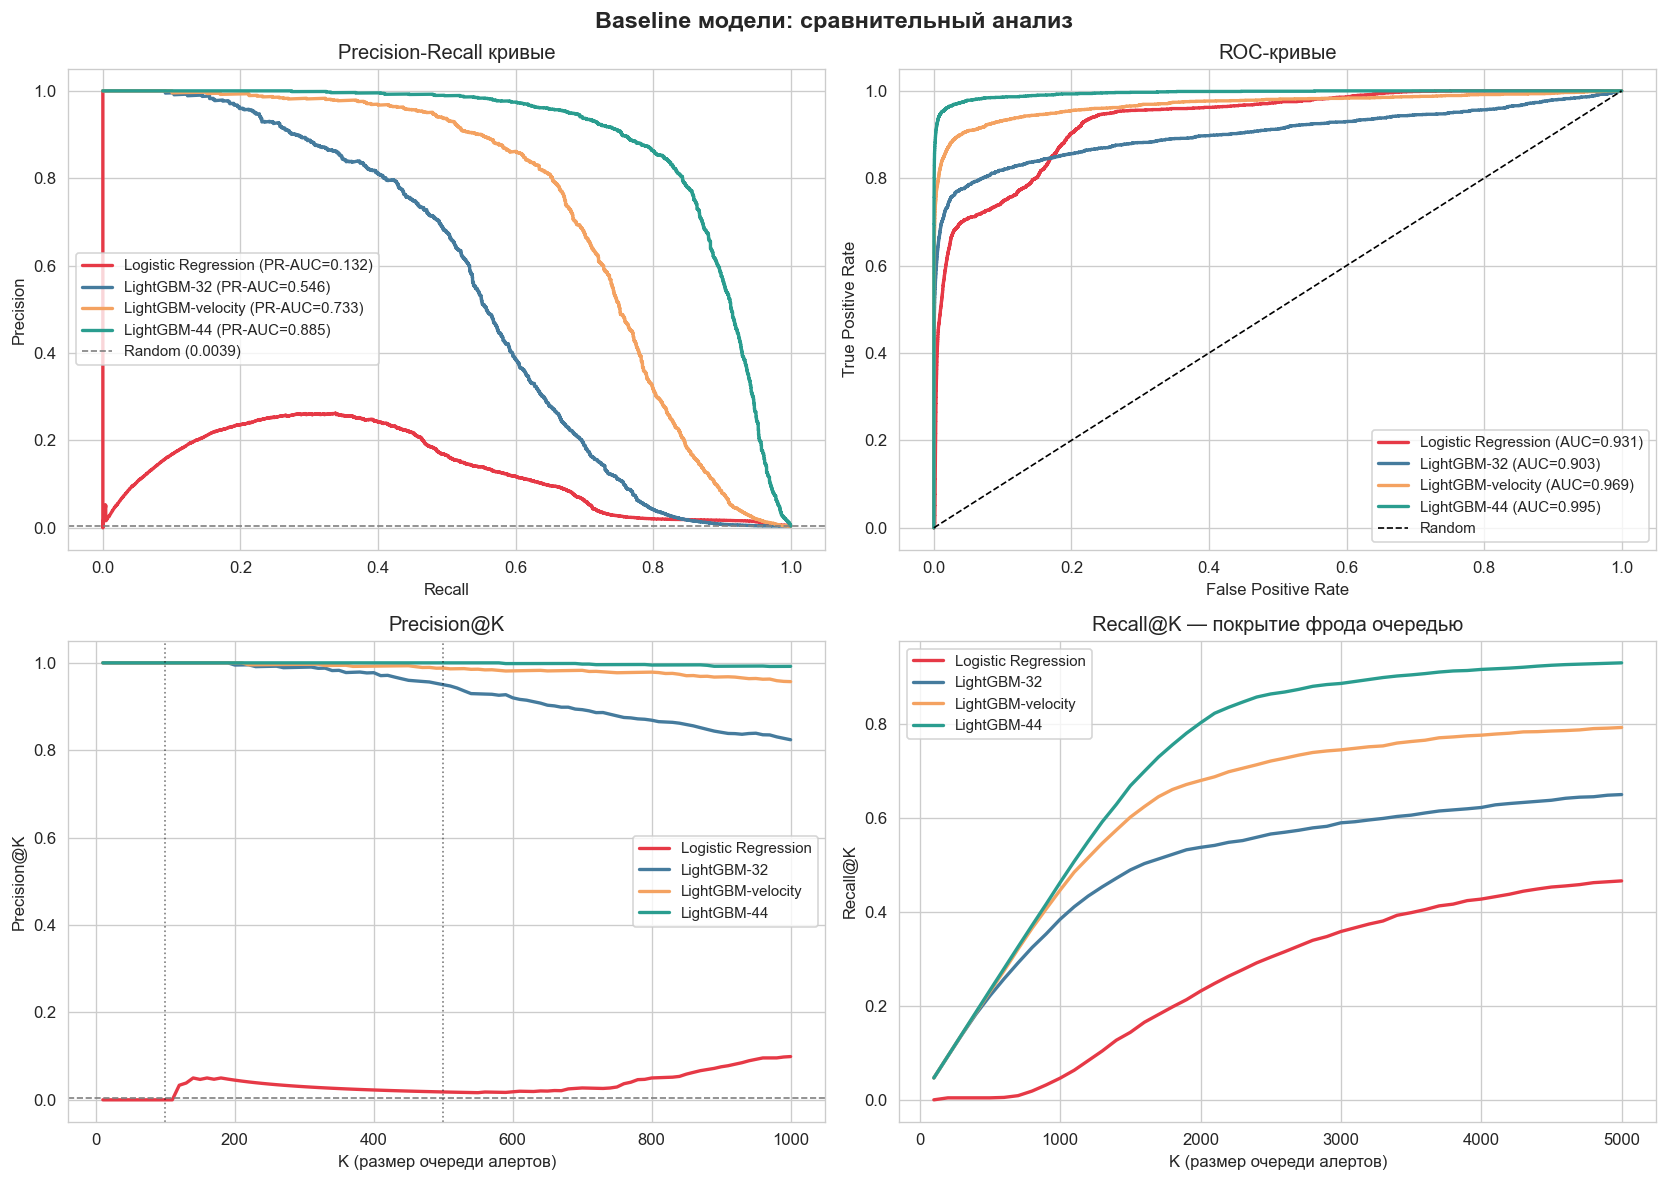

График сохранён: results/baseline_comparison.png


In [17]:
# Визуализация: четыре модели
MODELS_FOR_PLOTS = [
    ("Logistic Regression", lr_saved,            "#E63946"),
    ("LightGBM-32",         lgbm_saved,          "#457B9D"),
    ("LightGBM-velocity",   lgbm_velonly_scores, "#F4A261"),
    ("LightGBM-44",         lgbm_vel_scores,     "#2A9D8F"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Baseline модели: сравнительный анализ", fontsize=14, fontweight="bold")

# 1. PR-кривые
ax = axes[0, 0]
for name, scores, color in MODELS_FOR_PLOTS:
    prec, rec, _ = precision_recall_curve(y_test, scores)
    auc = average_precision_score(y_test, scores)
    ax.plot(rec, prec, color=color, lw=2, label=f"{name} (PR-AUC={auc:.3f})")
ax.axhline(y=y_test.mean(), color="gray", linestyle="--", lw=1,
           label=f"Random ({y_test.mean():.4f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall кривые"); ax.legend(fontsize=9)

# 2. ROC-кривые
ax = axes[0, 1]
for name, scores, color in MODELS_FOR_PLOTS:
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc = roc_auc_score(y_test, scores)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC-кривые"); ax.legend(fontsize=9)

# 3. Precision@K
ax = axes[1, 0]
k_values = list(range(10, 1001, 10))
for name, scores, color in MODELS_FOR_PLOTS:
    y_ranked = y_test.values[np.argsort(scores)[::-1]]
    ax.plot(k_values, [y_ranked[:k].mean() for k in k_values],
            color=color, lw=2, label=name)
ax.axhline(y=y_test.mean(), color="gray", linestyle="--", lw=1)
ax.axvline(x=100, color="black", linestyle=":", lw=1, alpha=0.5)
ax.axvline(x=500, color="black", linestyle=":", lw=1, alpha=0.5)
ax.set_xlabel("K (размер очереди алертов)"); ax.set_ylabel("Precision@K")
ax.set_title("Precision@K"); ax.legend(fontsize=9)

# 4. Recall@K — сколько фрода накрывает очередь заданного размера
ax = axes[1, 1]
n_fraud = y_test.sum()
k_values_r = list(range(100, 5001, 100))
for name, scores, color in MODELS_FOR_PLOTS:
    y_ranked = y_test.values[np.argsort(scores)[::-1]]
    ax.plot(k_values_r, [y_ranked[:k].sum() / n_fraud for k in k_values_r],
            color=color, lw=2, label=name)
ax.set_xlabel("K (размер очереди алертов)"); ax.set_ylabel("Recall@K")
ax.set_title("Recall@K — покрытие фрода очередью"); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS / "baseline_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("График сохранён: results/baseline_comparison.png")

## 8. Сохранение результатов

Сохраняем скоры обеих моделей в `results/` — они будут загружены
в Notebook 6 для финального сравнения всех методов.

Формат: CSV с колонками `y_true` и `score` — минимально необходимый
набор для пересчёта любых метрик в Notebook 6.

In [ ]:
import joblib

# Скоры для Notebook 6
for name, scores in [("lr", lr_scores), ("lgbm", lgbm_scores)]:
    pd.DataFrame({
        "y_true": y_test.values,
        "score":  scores,
    }).to_csv(RESULTS / f"scores_{name}.csv", index=False)
    print(f"Скоры сохранены: results/scores_{name}.csv")

# Сводная таблица метрик
metrics_df.to_csv(RESULTS / "metrics_baseline.csv")
print("Метрики сохранены: results/metrics_baseline.csv")

# Модели
joblib.dump(lr_pipeline,  MODELS / "lr_pipeline.pkl")
joblib.dump(lgbm_model,   MODELS / "lgbm_model.pkl")
print("Модели сохранены: models/lr_pipeline.pkl, models/lgbm_model.pkl")

# Параметры Optuna
with open(MODELS / "lgbm_best_params.json", "w") as f:
    json.dump(study.best_params, f, indent=2)
print("Параметры LightGBM сохранены: models/lgbm_best_params.json")

Скоры сохранены: results/scores_lr.csv
Скоры сохранены: results/scores_lgbm.csv
Метрики сохранены: results/metrics_baseline.csv
Модели сохранены: models/lr_pipeline.pkl, models/lgbm_model.pkl
Параметры LightGBM сохранены: models/lgbm_best_params.json


In [18]:
import joblib

# Скоры новых моделей (lr и lgbm уже лежат в results/ и не менялись)
for name, scores in [("lgbm_velocity", lgbm_velonly_scores),
                     ("lgbm_44",       lgbm_vel_scores)]:
    pd.DataFrame({"y_true": y_test.values, "score": scores}
                 ).to_csv(RESULTS / f"scores_{name}.csv", index=False)
    print(f"Скоры сохранены: results/scores_{name}.csv")

# Сводная таблица метрик: старые строки + две новые
metrics_old = pd.read_csv(RESULTS / "metrics_baseline.csv", index_col=0)
metrics_new = pd.DataFrame(
    [lgbm_velonly_results, lgbm_vel_results]).set_index("model")
metrics_df = pd.concat([metrics_old, metrics_new])
metrics_df = metrics_df[~metrics_df.index.duplicated(keep="last")]
metrics_df.to_csv(RESULTS / "metrics_baseline.csv")
print("Метрики обновлены: results/metrics_baseline.csv")
print(metrics_df[["pr_auc", "roc_auc", "precision@100", "precision@500"]].round(4))

# Модели и состав velocity-признаков
joblib.dump(lgbm_velonly_model, MODELS / "lgbm_velocity_model.pkl")
joblib.dump(lgbm_vel_model,     MODELS / "lgbm_44_model.pkl")
with open(MODELS / "velocity_cols.json", "w") as f:
    json.dump(VELOCITY_COLS, f, indent=2)
print("Модели сохранены: lgbm_velocity_model.pkl, lgbm_44_model.pkl")

Скоры сохранены: results/scores_lgbm_velocity.csv
Скоры сохранены: results/scores_lgbm_44.csv
Метрики обновлены: results/metrics_baseline.csv
                     pr_auc  roc_auc  precision@100  precision@500
model                                                             
Logistic Regression  0.1322   0.9311            0.0          0.018
LightGBM             0.5457   0.9033            1.0          0.950
LightGBM-velocity    0.7325   0.9692            1.0          0.988
LightGBM-44          0.8853   0.9950            1.0          1.000
Модели сохранены: lgbm_velocity_model.pkl, lgbm_44_model.pkl


In [19]:
# Замер времени инференса: единая сессия, батч 10 000 
import joblib

X_batch_32      = X_test.iloc[:10_000]
X_batch_vel     = X_test_vel.iloc[:10_000]
X_batch_velonly = X_test_velonly.iloc[:10_000]

lr_pipeline = joblib.load(MODELS / "lr_pipeline.pkl")
lgbm_model  = joblib.load(MODELS / "lgbm_model.pkl")

def bench(model, X, n_rep=7):
    _ = model.predict_proba(X)                      # прогрев
    times = []
    for _ in range(n_rep):
        t0 = time.perf_counter()
        _ = model.predict_proba(X)
        times.append((time.perf_counter() - t0) * 1000)
    return np.median(times)

for name, m, X in [("Logistic Regression", lr_pipeline,        X_batch_32),
                   ("LightGBM-32",         lgbm_model,         X_batch_32),
                   ("LightGBM-velocity",   lgbm_velonly_model, X_batch_velonly),
                   ("LightGBM-44",         lgbm_vel_model,     X_batch_vel)]:
    print(f"{name:<22} {bench(m, X):>8.1f} мс")

/Users/alex_erdenko/miniconda3/envs/fraud/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/alex_erdenko/miniconda3/envs/fraud/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/alex_erdenko/miniconda3/envs/fraud/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/alex_erdenko/miniconda3/envs/fraud/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/alex_erdenko/miniconda3/envs/fraud/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/alex_erdenko/miniconda3/envs/fraud/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users

Logistic Regression         1.6 мс
LightGBM-32                68.0 мс
LightGBM-velocity          55.2 мс
LightGBM-44                90.0 мс


## 9. Итоги Notebook 2

### Результаты baseline моделей

| Метрика | Logistic Regression | LightGBM-32 | LightGBM-velocity | LightGBM-44 |
|---|---|---|---|---|
| ROC-AUC | 0.9311 | 0.9033 | 0.9692 | 0.9950 |
| PR-AUC | 0.1322 | 0.5457 | 0.7325 | 0.8853 |
| F1 | 0.3042 | 0.5765 | 0.7208 | 0.8325 |
| Precision@100 | 0.0000 | 1.0000 | 1.0000 | 1.0000 |
| Recall@100 | 0.0000 | 0.0466 | 0.0466 | 0.0466 |
| NDCG@100 | 0.0000 | 1.0000 | 1.0000 | 1.0000 |
| Precision@500 | 0.0180 | 0.9500 | 0.9880 | 1.0000 |
| Recall@500 | 0.0042 | 0.2214 | 0.2303 | 0.2331 |
| NDCG@500 | 0.0182 | 0.9587 | 0.9900 | 1.0000 |
| Inference (10K)* | 1.6 мс | 68.0 мс | 55.2 мс | 90.0 мс |

### Ключевые выводы

- **Временно́й сигнал сильнее статического — внутри одного класса моделей.**
  12 velocity-признаков без единого статического (PR-AUC 0.733) существенно
  превосходят 32 статических признака (0.546) при идентичных гиперпараметрах.
  Ключевой носитель сигнала — отклонение от *скользящего* персонального
  профиля держателя (`amt_roll_z`), а не частотные счётчики: `cnt_1h`
  практически не используется моделью
- **Статика и динамика комплементарны:** комбинация LightGBM-44 (0.885)
  сильнее каждой группы по отдельности — две группы признаков описывают
  разные аспекты мошеннического поведения
- **LightGBM-44 — новая верхняя планка baseline-уровня** и главный ориентир
  для методов рекомендательных систем в финальном сравнении (Notebook 6)
- **Logistic Regression** подтверждает, что задача не решается линейными
  зависимостями; её высокий ROC-AUC (0.931) при Precision@100 = 0
  иллюстрирует, почему PR-AUC и метрики ранжирования при данном дисбалансе
  информативнее ROC-AUC
- Значения Precision@100 = 1.0 сразу у трёх конфигураций отражают специфику
  синтетического датасета с чёткими паттернами фрода; в реальных данных
  такого результата ожидать не следует

Все результаты сохранены в `results/` для финального сравнения в Notebook 6.